# 02 - Baseline

In [ ]:
import os, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import Dataset, DataLoader
from transformers import WavLMModel
from sklearn.metrics import roc_curve
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("CUDA:", torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

torch: 2.10.0+cu128
torchaudio: 2.10.0+cu128
CUDA: True Tesla T4


## Пути и конфиг

In [2]:
DATASET_ROOT = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset"
LA_ROOT = f"{DATASET_ROOT}/LA/LA"
PROTO_DIR = f"{LA_ROOT}/ASVspoof2019_LA_cm_protocols"
TRAIN_FLAC = f"{LA_ROOT}/ASVspoof2019_LA_train/flac"
DEV_FLAC = f"{LA_ROOT}/ASVspoof2019_LA_dev/flac"
PROTO_TRAIN = f"{PROTO_DIR}/ASVspoof2019.LA.cm.train.trn.txt"
PROTO_DEV = f"{PROTO_DIR}/ASVspoof2019.LA.cm.dev.trl.txt"

# конфиг эксперимента
DEVICE = torch.device("cuda")
MODEL_NAME = "microsoft/wavlm-large"
MAX_SECONDS = 6.0
SAMPLE_RATE = 16_000
MAX_SAMPLES = int(MAX_SECONDS * SAMPLE_RATE)
FEAT_DIR = "/kaggle/working/features_baseline"
SEED = 42

# гиперпараметры
BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 30
WEIGHT_BONAFIDE = 8.8

os.makedirs(FEAT_DIR, exist_ok=True)

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"MAX_SAMPLES: {MAX_SAMPLES:,}")
print(f"FEAT_DIR: {FEAT_DIR}")

MAX_SAMPLES: 96,000
FEAT_DIR: /kaggle/working/features_baseline


## Датасет

In [ ]:
LABEL2IDX = {"bonafide": 1, "spoof": 0}

def parse_protocol(path):
    rows = []
    with open(path) as f:
        for line in f:
            p = line.split()
            rows.append({"file_id": p[1], "attack": p[3], "label": p[4]})
    return pd.DataFrame(rows)

train_df = parse_protocol(PROTO_TRAIN)
dev_df   = parse_protocol(PROTO_DEV)
print(f"train: {len(train_df):,}  dev: {len(dev_df):,}")

class AudioDataset(Dataset):
    def __init__(self, df, flac_dir):
        self.df       = df.reset_index(drop=True)
        self.flac_dir = flac_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        wav, sr = torchaudio.load(f"{self.flac_dir}/{row.file_id}.flac")
        wav = wav.mean(0)  # моно

        if sr != SAMPLE_RATE:
            wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)

        # фиксируем длину: repeat-pad или обрезка
        if wav.numel() < MAX_SAMPLES:
            reps = MAX_SAMPLES // wav.numel() + 1
            wav  = wav.repeat(reps)[:MAX_SAMPLES]
        else:
            wav = wav[:MAX_SAMPLES]

        label = LABEL2IDX[row.label]
        return wav, label, row.file_id

train_ds = AudioDataset(train_df, TRAIN_FLAC)
dev_ds   = AudioDataset(dev_df,   DEV_FLAC)

# проверка одного сэмпла
wav, label, fid = train_ds[0]
print(f"сэмпл: {fid}  wav={wav.shape}  label={label}")

train: 25,380  dev: 24,844
сэмпл: LA_T_1138215  wav=torch.Size([96000])  label=1


## Загрузка WavLM


In [ ]:
model = WavLMModel.from_pretrained(MODEL_NAME)
model.eval()
model.to(DEVICE)

for p in model.parameters():
    p.requires_grad_(False)

n_params = sum(p.numel() for p in model.parameters())
print(f"WavLM Large: {n_params/1e6:.1f}M параметров")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/488 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

WavLM Large: 315.5M параметров


In [ ]:
def extract_features(dataset, split_name, batch_size=8):
    feat_path  = f"{FEAT_DIR}/{split_name}_features.npy"
    label_path = f"{FEAT_DIR}/{split_name}_labels.npy"

    if os.path.exists(feat_path):
        return np.load(feat_path), np.load(label_path)

    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)

    all_feats, all_labels = [], []

    with torch.no_grad():
        for wavs, labels, _ in tqdm(loader, desc=f"Extracting {split_name}"):
            wavs = wavs.to(DEVICE)   # (B, 96000)

            out  = model(wavs, output_hidden_states=False)
            # last_hidden_state: (B, T, 1024)
            feat = out.last_hidden_state.mean(dim=1)# (B, 1024)

            all_feats.append(feat.cpu().numpy())
            all_labels.append(labels.numpy())

    feats = np.concatenate(all_feats,  axis=0) # (N, 1024)
    labels = np.concatenate(all_labels, axis=0)# (N,)

    np.save(feat_path,  feats)
    np.save(label_path, labels)
    print(f"{split_name}: сохранено {feats.shape}  -  {feat_path}")
    return feats, labels

train_feats, train_labels = extract_features(train_ds, "train")
dev_feats,dev_labels  = extract_features(dev_ds, "dev")

print(f"\ntrain_feats : {train_feats.shape} labels: {train_labels.shape}")
print(f"dev_feats : {dev_feats.shape} labels: {dev_labels.shape}")

Extracting train:   0%|          | 0/3173 [00:00<?, ?it/s]

train: сохранено (25380, 1024)  -  /kaggle/working/features_baseline/train_features.npy


Extracting dev:   0%|          | 0/3106 [00:00<?, ?it/s]

dev: сохранено (24844, 1024)  -  /kaggle/working/features_baseline/dev_features.npy

train_feats : (25380, 1024) labels: (25380,)
dev_feats : (24844, 1024) labels: (24844,)


## Линейный классификатор

In [ ]:
class LinearProbe(nn.Module):
    def __init__(self, in_dim=1024, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(in_dim, n_classes)

    def forward(self, x):
        return self.fc(x)


class FeatDataset(Dataset):
    def __init__(self, feats, labels):
        self.feats  = torch.tensor(feats,  dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.feats[i], self.labels[i]


train_feat_ds = FeatDataset(train_feats, train_labels)
dev_feat_ds = FeatDataset(dev_feats,   dev_labels)

train_loader = DataLoader(train_feat_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0)
dev_loader = DataLoader(dev_feat_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0)

probe = LinearProbe().to(DEVICE)
n_trainable = sum(p.numel() for p in probe.parameters() if p.requires_grad)
print(f"LinearProbe: {n_trainable:,} параметров")

weights = torch.tensor([1.0, WEIGHT_BONAFIDE], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(probe.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                 optimizer, mode="min", factor=0.5, patience=3)

LinearProbe: 2,050 параметров


In [ ]:
def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2
    thr = thresholds[idx]
    return eer * 100, thr

In [ ]:
def run_epoch(loader, probe, criterion, optimizer=None):
    is_train = optimizer is not None
    probe.train() if is_train else probe.eval()

    total_loss, all_labels, all_scores = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for feats, labels in loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            logits = probe(feats)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            scores = torch.softmax(logits, dim=1)[:, 1]
            total_loss  += loss.item() * len(labels)
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(scores.detach().cpu().numpy())  # ← фикс

    avg_loss = total_loss / len(loader.dataset)
    eer, _ = compute_eer(np.array(all_labels), np.array(all_scores))
    return avg_loss, eer

In [30]:
history = {"train_loss": [], "train_eer": [], "dev_loss": [], "dev_eer": []}
best_dev_eer = float("inf")
best_epoch = -1
patience_cnt = 0
PATIENCE = 7

print(f"{'Epoch':>6} {'Train Loss':>11} {'Train EER':>10} "
      f"{'Dev Loss':>10} {'Dev EER':>9}")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_eer = run_epoch(train_loader, probe, criterion, optimizer)
    dv_loss, dv_eer = run_epoch(dev_loader,   probe, criterion)
    scheduler.step(dv_loss)

    history["train_loss"].append(tr_loss)
    history["train_eer"].append(tr_eer)
    history["dev_loss"].append(dv_loss)
    history["dev_eer"].append(dv_eer)

    marker = ""
    if dv_eer < best_dev_eer:
        best_dev_eer = dv_eer
        best_epoch   = epoch
        patience_cnt = 0
        torch.save(probe.state_dict(), "/kaggle/working/best_probe.pt")
        marker = "  best"
    else:
        patience_cnt += 1


    print(f"{epoch:>6} {tr_loss:>11.4f} {tr_eer:>9.2f}% "
          f"{dv_loss:>10.4f} {dv_eer:>8.2f}%{marker}", flush=True)

    if patience_cnt >= PATIENCE:
        print(f"\nEarly stopping на эпохе {epoch}"); break

print(f"\nЛучший dev EER: {best_dev_eer:.2f}%")

 Epoch  Train Loss  Train EER   Dev Loss   Dev EER
     1      0.3335     11.36%     0.2544     9.14%  best
     2      0.1939      6.17%     0.1866     7.33%  best
     3      0.1531      4.37%     0.1575     6.01%  best
     4      0.1290      3.60%     0.1292     4.99%  best
     5      0.1121      3.05%     0.1163     4.67%  best
     6      0.0997      2.50%     0.1094     4.27%  best
     7      0.0903      2.13%     0.0882     3.71%  best
     8      0.0816      1.90%     0.0814     3.67%  best
     9      0.0750      1.70%     0.0789     3.26%  best
    10      0.0690      1.58%     0.0706     3.10%  best
    11      0.0637      1.30%     0.0694     2.87%  best
    12      0.0597      1.33%     0.0656     2.60%  best
    13      0.0559      1.13%     0.0619     2.59%  best
    14      0.0528      1.08%     0.0558     2.47%  best
    15      0.0496      0.98%     0.0490     2.52%
    16      0.0467      0.98%     0.0467     2.35%  best
    17      0.0446      0.85%     0.0478   

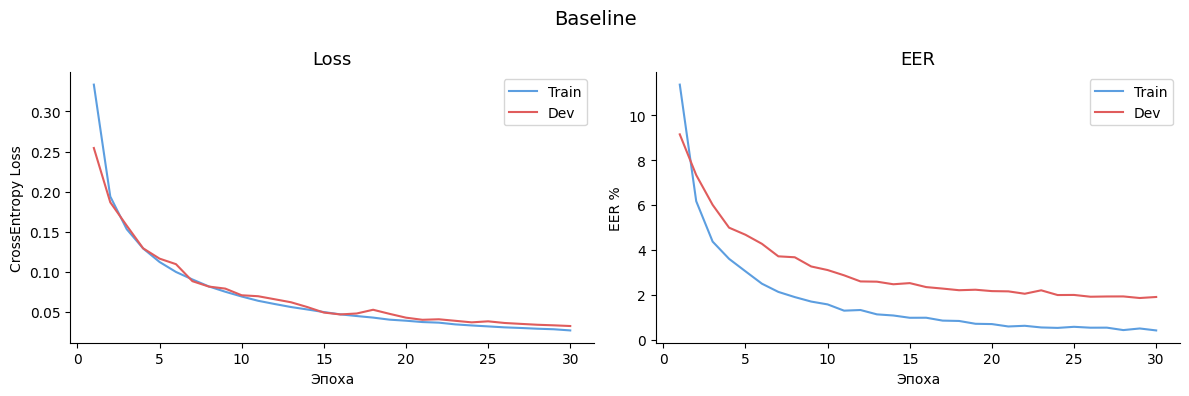

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)

# Loss
ax1.plot(epochs, history["train_loss"], color="#5c9ee0", label="Train")
ax1.plot(epochs, history["dev_loss"],   color="#e05c5c", label="Dev")
ax1.set_title("Loss", fontsize=13)
ax1.set_xlabel("Эпоха")
ax1.set_ylabel("CrossEntropy Loss")
ax1.legend()
ax1.spines[["top", "right"]].set_visible(False)

# EER
ax2.plot(epochs, history["train_eer"], color="#5c9ee0", label="Train")
ax2.plot(epochs, history["dev_eer"],   color="#e05c5c", label="Dev")
ax2.set_title("EER", fontsize=13)
ax2.set_xlabel("Эпоха")
ax2.set_ylabel("EER %")
ax2.legend()
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("Baseline",
             fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
print("РЕЗУЛЬТАТЫ")
print(f"Модель: WavLM Large")
print(f"Признаки: последний слой, mean pooling")
print(f"Классификатор: Linear(1024, 2)")
print(f"Параметров: 2,050")
print(f"Обучаемых слоёв: 0 (WavLM) + 1 (Linear)")
print(f"Лучшая эпоха: {best_epoch}")
print(f"Train EER: {history['train_eer'][best_epoch-1]:.2f}%")
print(f"Dev EER: {best_dev_eer:.2f}%")

РЕЗУЛЬТАТЫ
Модель: WavLM Large
Признаки: последний слой, mean pooling
Классификатор: Linear(1024, 2)
Параметров: 2,050
Обучаемых слоёв: 0 (WavLM) + 1 (Linear)
Лучшая эпоха: 29
Train EER: 0.50%
Dev EER: 1.86%


In [33]:
# загружаем лучший чекпоинт
probe.load_state_dict(torch.load("/kaggle/working/best_probe.pt"))
probe.eval()

def get_scores(loader):
    """Возвращает метки и скоры P(bonafide) для всего сплита."""
    all_labels, all_scores = [], []
    with torch.no_grad():
        for feats, labels in loader:
            feats   = feats.to(DEVICE)
            logits  = probe(feats)
            scores  = torch.softmax(logits, dim=1)[:, 1]  # P(bonafide)
            all_labels.extend(labels.numpy())
            all_scores.extend(scores.cpu().numpy())
    return np.array(all_labels), np.array(all_scores)

dev_labels_arr, dev_scores_arr = get_scores(dev_loader)
final_eer, final_thr = compute_eer(dev_labels_arr, dev_scores_arr)
print(f"Финальный dev EER: {final_eer:.2f}%")
print(f"Порог EER: {final_thr:.4f}")

Финальный dev EER: 1.86%
Порог EER: 0.2461


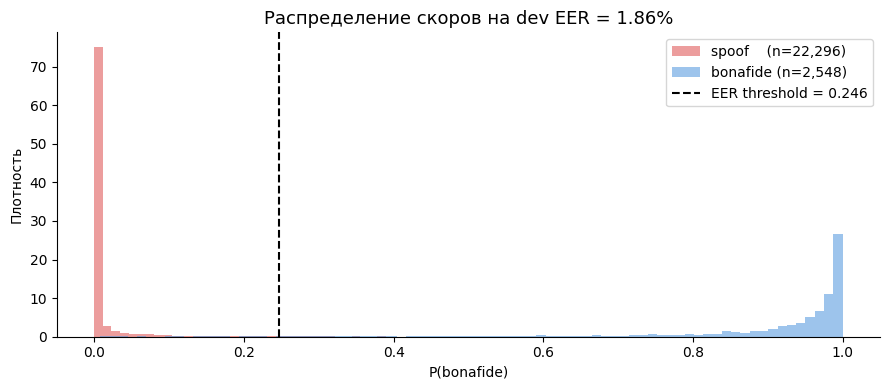

bonafide скоры:  mean=0.904  std=0.168
spoofскоры:  mean=0.016  std=0.067


In [34]:
fig, ax = plt.subplots(figsize=(9, 4))

bon_scores = dev_scores_arr[dev_labels_arr == 1]
spo_scores = dev_scores_arr[dev_labels_arr == 0]

ax.hist(spo_scores, bins=80, alpha=0.6, color="#e05c5c",
        label=f"spoof    (n={len(spo_scores):,})", density=True)
ax.hist(bon_scores, bins=80, alpha=0.6, color="#5c9ee0",
        label=f"bonafide (n={len(bon_scores):,})", density=True)

ax.axvline(final_thr, color="black", linestyle="--", linewidth=1.5,
           label=f"EER threshold = {final_thr:.3f}")

ax.set_xlabel("P(bonafide)")
ax.set_ylabel("Плотность")
ax.set_title(f"Распределение скоров на dev EER = {final_eer:.2f}%", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"bonafide скоры:  mean={bon_scores.mean():.3f}  std={bon_scores.std():.3f}")
print(f"spoofскоры:  mean={spo_scores.mean():.3f}  std={spo_scores.std():.3f}")

   Атака     EER%    Файлов
     A06    3.79%      3716
     A04    0.91%      3716
     A02    0.58%      3716
     A03    0.44%      3716
     A01    0.17%      3716
     A05    0.16%      3716


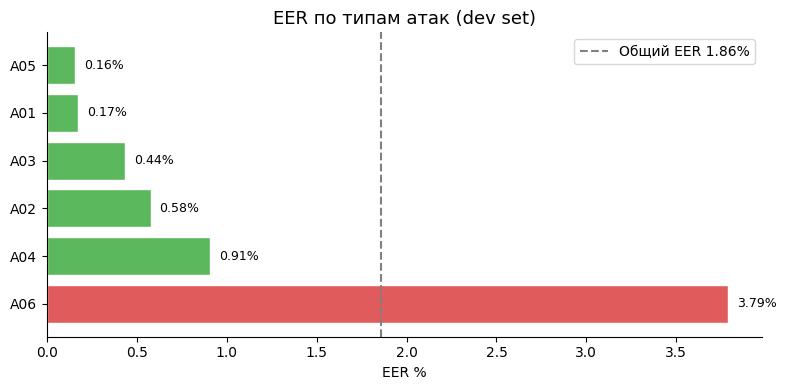

In [ ]:
dev_df_scored = dev_df.copy().reset_index(drop=True)
dev_df_scored["score"] = dev_scores_arr
dev_df_scored["label_idx"] = dev_labels_arr

attacks = sorted(dev_df_scored[dev_df_scored.attack != "-"].attack.unique())

rows = []
bonafide_mask = dev_df_scored.attack == "-"

for attack in attacks:
    attack_mask = dev_df_scored.attack == attack
    subset = dev_df_scored[bonafide_mask | attack_mask]
    eer, _ = compute_eer(subset["label_idx"].values, subset["score"].values)
    n = attack_mask.sum()
    rows.append({"attack": attack, "EER%": eer, "n_files": n})

attack_df = pd.DataFrame(rows).sort_values("EER%", ascending=False)

# таблица
print(f"{'Атака':>8}  {'EER%':>7}  {'Файлов':>8}")
for _, row in attack_df.iterrows():
    print(f"{row['attack']:>8}  {row['EER%']:>6.2f}%  {int(row['n_files']):>8}")

# график
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#e05c5c" if e > 3 else "#f0a05c" if e > 1 else "#5cb85c"
          for e in attack_df["EER%"]]
bars = ax.barh(attack_df["attack"], attack_df["EER%"],
               color=colors, edgecolor="white")
ax.axvline(final_eer, linestyle="--", color="gray",
           label=f"Общий EER {final_eer:.2f}%")
ax.set_xlabel("EER %")
ax.set_title("EER по типам атак (dev set)", fontsize=13)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

for bar, val in zip(bars, attack_df["EER%"]):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
def bootstrap_eer_ci(labels, scores, n_bootstrap=1000, ci=95):
    rng = np.random.default_rng(SEED)
    n = len(labels)
    eers = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        eer, _ = compute_eer(labels[idx], scores[idx])
        eers.append(eer)
    eers = np.array(eers)
    lo = np.percentile(eers, (100 - ci) / 2)
    hi = np.percentile(eers, 100 - (100 - ci) / 2)
    return np.mean(eers), lo, hi

In [38]:
SEEDS = [42, 1, 2026]
baseline_seed_results = []

for seed in SEEDS:
    set_seed(seed)
    probe_s  = LinearProbe().to(DEVICE)
    opt_s  = torch.optim.Adam(probe_s.parameters(), lr=LR)
    crit_s  = nn.CrossEntropyLoss(
        weight=torch.tensor([1.0, WEIGHT_BONAFIDE],
                            dtype=torch.float32).to(DEVICE))
    sched_s  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt_s, mode="min", factor=0.5, patience=3)

    best_eer_s, pat_s, best_state = float("inf"), 0, None

    for epoch in range(NUM_EPOCHS):
        run_epoch(train_loader, probe_s, crit_s, opt_s)
        _, dv_eer = run_epoch(dev_loader, probe_s, crit_s)
        sched_s.step(dv_eer)
        if dv_eer < best_eer_s:
            best_eer_s = dv_eer
            best_state = {k: v.clone() for k, v in probe_s.state_dict().items()}
            pat_s = 0
        else:
            pat_s += 1
        if pat_s >= PATIENCE:
            break

    probe_s.load_state_dict(best_state)
    probe_s.eval()
    all_l, all_s = [], []
    with torch.no_grad():
        for feats, labels in dev_loader:
            logits = probe_s(feats.to(DEVICE))
            scores = torch.softmax(logits, dim=1)[:, 1]
            all_l.extend(labels.numpy())
            all_s.extend(scores.cpu().numpy())
    eer_final, _ = compute_eer(np.array(all_l), np.array(all_s))
    _, lo_s, hi_s = bootstrap_eer_ci(np.array(all_l), np.array(all_s))
    baseline_seed_results.append({"seed": seed, "eer": eer_final,
                                  "ci_lo": lo_s, "ci_hi": hi_s})
    print(f"seed={seed:>5}  EER={eer_final:.3f}%  "
          f"95%CI=[{lo_s:.3f}%, {hi_s:.3f}%]", flush=True)

eers = [r["eer"] for r in baseline_seed_results]
mean_b = np.mean(eers)
std_b = np.std(eers)
print(f"\nBaseline: EER = {mean_b:.3f}% ± {std_b:.3f}%")

seed=   42  EER=1.802%  95%CI=[1.539%, 2.090%]
seed=    1  EER=1.842%  95%CI=[1.625%, 2.163%]
seed= 2026  EER=1.844%  95%CI=[1.564%, 2.116%]

Baseline: EER = 1.829% ± 0.019%
